<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Date             4000 non-null   object
 1   City             4000 non-null   object
 2   Area_Type        4000 non-null   object
 3   Water_Demand     4000 non-null   int64 
 4   Temperature      4000 non-null   int64 
 5   Rainfall         4000 non-null   int64 
 6   Population       4000 non-null   int64 
 7   Reservoir_Level  4000 non-null   int64 
 8   Water_Tariff     4000 non-null   int64 
 9   Weather          4000 non-null   object
 10  Season           4000 non-null   object
 11  Holiday          4000 non-null   int64 
dtypes: int64(7), object(5)
memory usage: 375.1+ KB
None
Date               0
City               0
Area_Type          0
Water_Demand       0
Temperature        0
Rainfall           0
Population         0
Reservoir_Level    0
Water_Tariff       0
Weather          

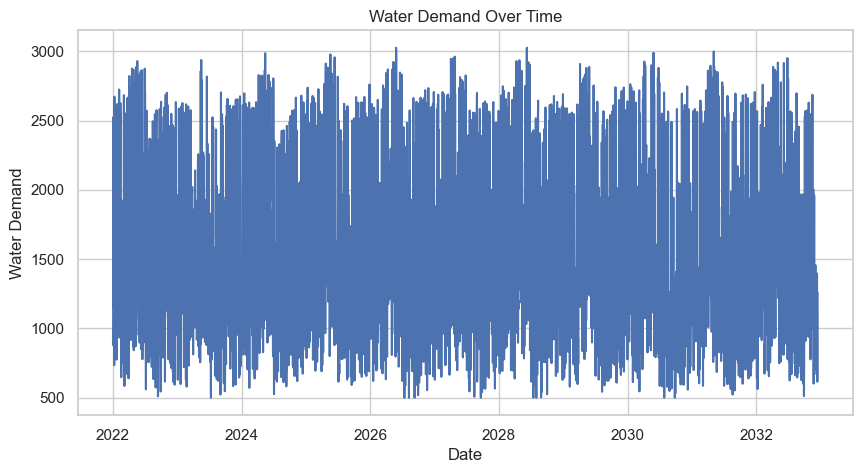

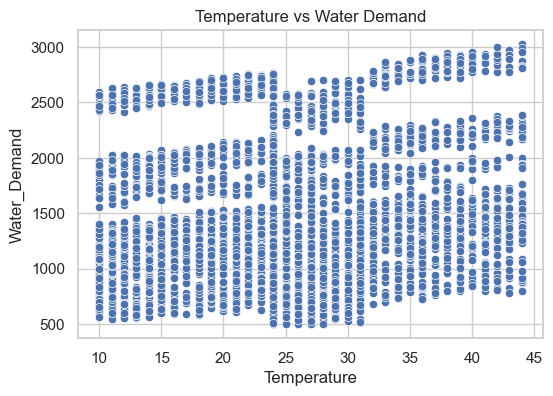

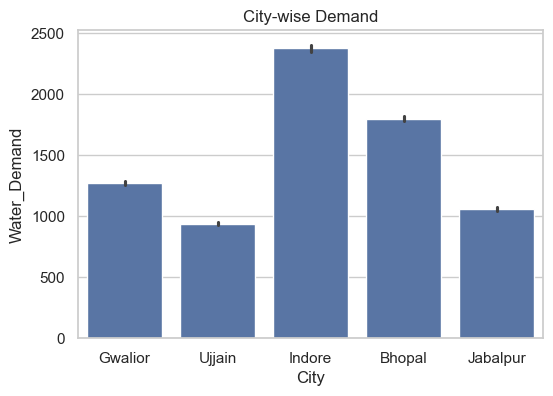

MAE: 51.25249061326659
R2 Score: 0.9888857147710751


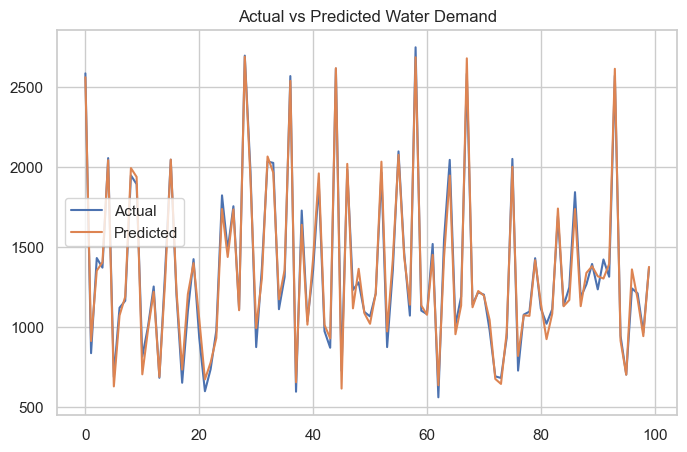

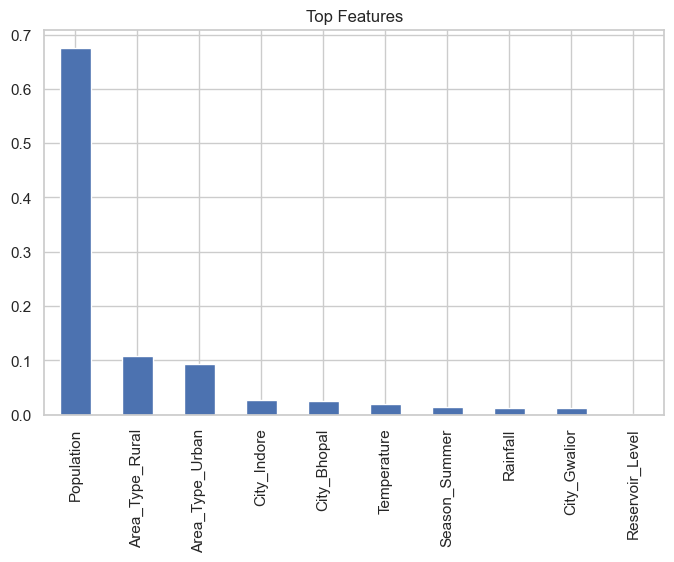

In [1]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set(style="whitegrid")
 
# 2. LOAD DATA 
data = pd.read_csv("mp_water_demand_4000_rows.csv")
 
# 3. BASIC INFO 
print(data.info())
print(data.isnull().sum())
 
# 4. DATE FEATURE ENGINEERING
data["Date"] = pd.to_datetime(data["Date"])

data["year"] = data["Date"].dt.year
data["month"] = data["Date"].dt.month
data["day"] = data["Date"].dt.day
data["weekday"] = data["Date"].dt.weekday
 
# 5. EDA (VISUALIZATION) 
# Demand over time
plt.figure(figsize=(10,5))
plt.plot(data["Date"], data["Water_Demand"])
plt.title("Water Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Water Demand")
plt.show()

# Temperature vs Demand
plt.figure(figsize=(6,4))
sns.scatterplot(x=data["Temperature"], y=data["Water_Demand"])
plt.title("Temperature vs Water Demand")
plt.show()

# City wise demand
plt.figure(figsize=(6,4))
sns.barplot(x="City", y="Water_Demand", data=data)
plt.title("City-wise Demand")
plt.show()
 
# 6. FEATURE ENGINEERING (ADVANCED) 
# Lag features (IMPORTANT FOR TIME SERIES)
data = data.sort_values("Date")

data["lag_1"] = data["Water_Demand"].shift(1)
data["lag_7"] = data["Water_Demand"].shift(7)

data = data.dropna()
 
# 7. DROP DATE (AFTER USING IT) 
data = data.drop("Date", axis=1)
 
# 8. ENCODING 
data = pd.get_dummies(data)
 
# 9. SPLIT DATA (TIME BASED) 
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

X_train = train.drop("Water_Demand", axis=1)
y_train = train["Water_Demand"]

X_test = test.drop("Water_Demand", axis=1)
y_test = test["Water_Demand"]
 
# 10. MODEL TRAINING 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train) 

# 11. PREDICTION 
y_pred = model.predict(X_test)
 
# 12. EVALUATION 
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
 
# 13. ACTUAL vs PREDICTED GRAPH 
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Water Demand")
plt.show()
 
# 14. FEATURE IMPORTANCE 
importances = model.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()


# from sklearn.metrics import mean_squared_error 

# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# print(rmse)

In [ ]:
import joblib

joblib.dump(model, "water_model.pkl")
joblib.dump(X_train.columns, "columns.pkl")

print("✅ Model saved")

✅ Model saved
